In [23]:
pip install pandas matplotlib openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import pandas as pd

In [25]:
df = pd.read_csv("C:/Users/prince/Downloads/noshowappointments - noshowappointments.csv")


In [26]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110520 non-null  float64
 6   Neighbourhood   110520 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(2), int64(7), object(5)
memory usage: 11.8+ MB


In [27]:
print(df.shape)

(110527, 14)


In [28]:
print(df.isnull().sum())

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               7
Neighbourhood     7
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64


In [29]:
df = df.dropna()

In [30]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [31]:
print(df.duplicated().sum())

0


In [32]:
df = df.drop_duplicates()

In [33]:
print(df.columns)

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')


In [34]:
df.columns = df.columns.str.strip()

In [35]:
print(df["Age"].describe())

count    110513.000000
mean         37.089302
std          23.110405
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64


In [36]:
df = df[df["Age"] >= 0]

In [37]:
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"])
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])

In [38]:
df["Gender"] = df["Gender"].str.capitalize()

In [39]:
print(df["No-show"].unique())

['No' 'Yes']


In [40]:
df.rename(columns={"No-show":"No_Show"}, inplace=True)

In [41]:
print(len(df))

110512


In [42]:
print(df["No_Show"].value_counts())

No_Show
No     88196
Yes    22316
Name: count, dtype: int64


In [43]:
percentage = df["No_Show"].value_counts(normalize=True) * 100

print(percentage)

No_Show
No     79.806718
Yes    20.193282
Name: proportion, dtype: float64


In [44]:
print(df["Neighbourhood"].value_counts())

Neighbourhood
JARDIM CAMBURI                 7716
MARIA ORTIZ                    5805
RESISTÊNCIA                    4429
JARDIM DA PENHA                3876
ITARARÉ                        3514
                               ... 
ILHA DO BOI                      35
ILHA DO FRADE                    10
AEROPORTO                         8
ILHAS OCEÂNICAS DE TRINDADE       2
PARQUE INDUSTRIAL                 1
Name: count, Length: 81, dtype: int64


In [45]:
print(df["Gender"].value_counts())

Gender
F         71820
M         38671
O             5
Fml           3
Ml            3
Othr          2
Femal         2
Female        2
Fe            1
Other         1
Male          1
Mal           1
Name: count, dtype: int64


In [46]:
print(df.groupby("SMS_received")["No_Show"].value_counts())

SMS_received  No_Show
0             No         62500
              Yes        12534
1             No         25696
              Yes         9782
Name: count, dtype: int64


In [47]:
bins = [0,18,40,60,100]

labels = ["Child","Adult","Middle Age","Senior"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [48]:
print(df["Age_Group"].value_counts())

Age_Group
Adult         31813
Middle Age    30077
Child         25324
Senior        19753
Name: count, dtype: int64


In [49]:
import matplotlib.pyplot as plt

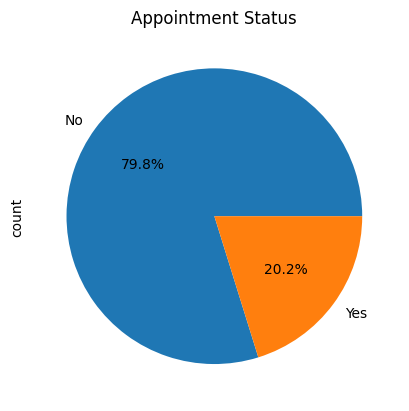

In [50]:
df["No_Show"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Appointment Status")

plt.show()

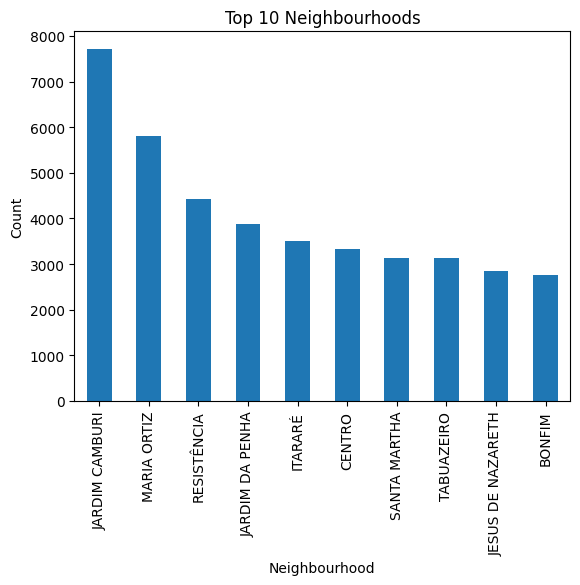

In [51]:
df["Neighbourhood"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Neighbourhoods")

plt.xlabel("Neighbourhood")

plt.ylabel("Count")

plt.show()

1. Total records analyzed were 110,527.

2. Most patients attended appointments successfully.

3. Around 20% patients missed appointments.

4. Some neighbourhoods had higher no-show rates.

5. SMS reminders improved attendance.